# Error Codes

In classical devices, high energy particles (cosmic rays, neutrons produced in the earth’s atmosphere, radiation from nuclear testing, radiation from particle accelerator) can strike computers and cause bits to flip from $0$ to $1$ or from $1$ to $0$. Some bits may also become corrupted when transmitted through the internet.

Similarly, quantum devices face errors due to noise (thermal fluctuations, electromagnetic interference, stray atoms, etc.), decoherence, and more. In this demonstration, we illustrate the concept of quantum error detection.

1. [Quantum Error](#1.-Quantum-Error)
2. [Quantum Error Detection](#2.-Quantum-Error-Detection)
3. [Qiskit Implementation](#3.-Qiskit-Implementation)

IBM Quantum Composer: https://quantum.ibm.com/composer/

## 1. Quantum Error
We will begin with the $\ket{00}$ state. To simulate an simple bit flip error, we can simply apply an $X$ gate to the second qubit. In more complicated cases, the qubit may experience partial bit flips or phase flips.


This results in the $\ket{10}$ state.

<img src="error_codes_images/bitflip.png"></img>

## 2. Quantum Error Detection
Given that we know the original error-free state, we can detect if any changes in the state had occurred with **parity checking**. **Parity** refers to whether the bit string has an even or odd number of $1$’s. If there is an even number of $1$'s, the output is $0$. If there is an odd number of $1$'s, the output is $1$.

In this case, our original state is $\ket{00}$. The **parity** of this state is $0$. 

To measure the parity without collapsing the original state, we add an **ancilla** (extra) qubit to store the parity. We apply $\text{CNOT}$ gates to the circuit for every qubit, with that qubit as the control and the **ancilla** qubit as the target.

<img src="error_codes_images/error_codes.png"></img>

Measuring the **ancilla** qubit, we see the result to be $\ket{1}$. This differs from our original known parity, $0$. That means an error must have occurred.

<img src="error_codes_images/error_codes_measurement.png"></img>

## 3. Qiskit Implementation
We implement this in Qiskit.

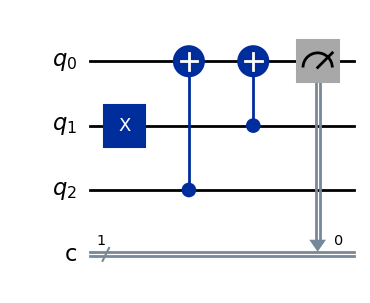

In [1]:
from qiskit import QuantumCircuit

# Create a quantum circuit with 3 qubits and 1 classical bit for measurement
qc = QuantumCircuit(3, 1)

# Step 1: Showcase simple error
# Initialize the qubits in the |00⟩ state 

# Apply X gate to the second qubit to simulate a bit flip error
qc.x(1)  # Apply X gate to qubit 1 (second qubit)

# Step 2: Construct simple error detection (parity checking)
# Add parity checking using a third qubit (ancilla)

# Apply CNOT with qubit 0 (first qubit) as control and qubit 2 (third qubit) as target
qc.cx(2, 0)  

# Apply CNOT with qubit 1 (second qubit) as control and qubit 2 (third qubit) as target
qc.cx(1, 0)  

#Measure the ancilla qubit and store result in the classical bit
qc.measure(0, 0)  

# Visualize the circuit
qc.draw(output='mpl')

In [2]:
from qiskit_aer import AerSimulator

simulator = AerSimulator()
job = simulator.run(qc, shots=1000) # How many copies of the circuit are executed

# Get the result and count the occurrences of each outcome
result = job.result()
counts = result.get_counts(qc)

print("Measurement results:", counts)

Measurement results: {'1': 1000}


## Quantum Error Correction — Multiple Choice

### Question 1  
What type of error does a bit-flip error represent?

A) Phase error  
B) Amplitude damping  
C) X error (0 ↔ 1)  
D) Measurement error  

**Answer:** C

---

### Question 2  
How does the 3-qubit bit-flip code protect information?

A) By measuring the qubit directly  
B) By copying the qubit into three qubits  
C) By applying random gates  
D) By removing entanglement  

**Answer:** B

---

### Question 3  
What is the purpose of syndrome measurement?

A) To destroy the quantum state  
B) To detect which qubit has an error  
C) To randomize outputs  
D) To reset the circuit  

**Answer:** B

---

### Question 4  
If one qubit flips in a 3-qubit bit-flip code, how is it corrected?

A) Ignore the error  
B) Measure and discard the system  
C) Apply an X gate to the incorrect qubit  
D) Apply H gates to all qubits  

**Answer:** C

---

### Question 5  
What is the expected measurement behavior after error correction?

A) Completely random results  
B) All qubits disagree  
C) Original encoded value is recovered  
D) Only one qubit remains valid  

**Answer:** C